In [1]:
from sklearn.datasets import make_regression
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import cross_val_score

In [3]:
X,y = make_regression(n_samples = 100,n_features = 1 , n_informative = 1,n_targets = 1,noise = 20,random_state = 0)

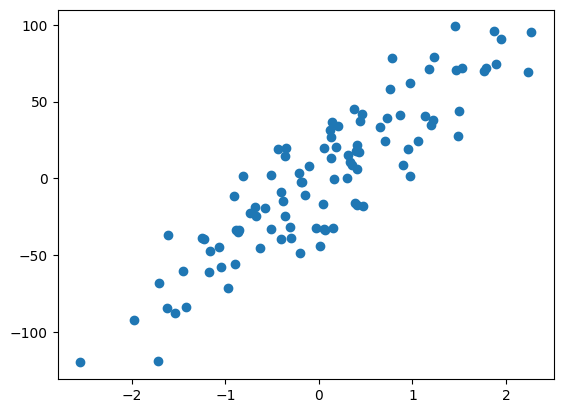

In [4]:
plt.scatter(X,y)

In [5]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)

In [6]:
from sklearn.linear_model import LinearRegression

In [7]:
lr = LinearRegression()

In [8]:
lr.fit(X_train,y_train)
print(lr.coef_)
print(lr.intercept_)

[42.76266569]
-2.1851409277693836


In [9]:
y_pred = lr.predict(X_test)
from sklearn.metrics import r2_score
r2_score(y_test,y_pred)

0.7704615425059335

In [17]:
class GDRegressor:
    def __init__(self,learning_rate,epochs):
        self.m = 100
        self.b = -120
        self.lr = learning_rate
        self.epochs = epochs
    def fit(self,X,y):
        for i in range(self.epochs):
            loss_slope_b = -2 * np.sum(y - self.m * X.ravel() - self.b)
            self.b = self.b - (self.lr * loss_slope_b)
            loss_slope_m = -2 * np.sum((y - self.m*X.ravel() - self.b) * X.ravel())
            self.m = self.m - (self.lr * loss_slope_m)
        print(self.m,self.b)
    def predict(self,X):
        return self.m * X + self.b

In [20]:
gd = GDRegressor(0.001,50)

In [21]:
gd.fit(X_train,y_train)

42.7726218653376 -2.2101701295429517


In [23]:
y_pred = gd.predict(X_test)
from sklearn.metrics import r2_score
r2_score(y_test,y_pred) # cv karye cheye to GDRegressor naam nu sklearn ma gote che so r2

0.7703765699933843